In [2]:
# Import library pandas
import pandas as pd

# 1. Membaca file CSV yang telah dibuat menjadi DataFrame
df = pd.read_csv("Peserta_Semifinal_OSN_2026.csv")

# 2. Menampilkan 5 baris pertama dari data
display(df.head())

# 3. Melihat informasi umum dari DataFrame (tipe data, jumlah baris, dan apakah ada data yang kosong/null)
print("\n--- Info DataFrame ---")
df.info()

,NO,CABANG,NAMA,NPSN,SEKOLAH,KABUPATEN / KOTA,PROVINSI
0,1,ASTRONOMI,MUHAMMAD GENTA KSATRIA BUMI,20623314,MAN INSAN CENDEKIA SERPONG,KOTA TANGERANG SELATAN,PROV. BANTEN
1,2,ASTRONOMI,NIBRAS IZZUL HAQ,20327563,SMAN 1 MAGELANG,KOTA MAGELANG,PROV. JAWA TENGAH
2,3,ASTRONOMI,AZZAH FIKRAH CHALISAH,69983368,MAN INSAN CENDEKIA PADANG PARIAMAN,KAB. PADANG PARIAMAN,PROV. SUMATERA BARAT
3,4,ASTRONOMI,MUHAMMAD RIDHOWAN,40303176,SMAN 2 WAJO,KAB. WAJO,PROV. SULAWESI SELATAN
4,5,ASTRONOMI,ALVINO YARDAN WIRADHARMA,30401067,SMA NEGERI 10 SAMARINDA,KOTA SAMARINDA,PROV. KALIMANTAN TIMUR



--- Info DataFrame ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   NO                900 non-null    int64 
 1   CABANG            900 non-null    object
 2   NAMA              900 non-null    object
 3   NPSN              900 non-null    int64 
 4   SEKOLAH           900 non-null    object
 5   KABUPATEN / KOTA  900 non-null    object
 6   PROVINSI          900 non-null    object
dtypes: int64(2), object(5)
memory usage: 49.3+ KB


In [3]:
# Menghitung jumlah peserta per provinsi
print("\n--- Jumlah Peserta per Provinsi ---")
display(df['PROVINSI'].value_counts())


--- Jumlah Peserta per Provinsi ---


,count
PROVINSI,
PROV. D.K.I. JAKARTA,116
PROV. JAWA TIMUR,104
PROV. JAWA TENGAH,100
PROV. JAWA BARAT,68
PROV. BANTEN,51
PROV. RIAU,39
PROV. SUMATERA UTARA,29
PROV. D.I. YOGYAKARTA,28
PROV. SUMATERA SELATAN,28


In [4]:
# Menghitung 20 sekolah dengan peserta terbanyak
top_20_sekolah = df['SEKOLAH'].value_counts().head(20)

print("--- Top 20 Sekolah dengan Peserta Terbanyak ---")
display(top_20_sekolah)

--- Top 20 Sekolah dengan Peserta Terbanyak ---


,count
SEKOLAH,
MAN 2,17
MAN INSAN CENDEKIA SERPONG,15
SMAS KRISTEN BPK PENABUR GADING SERPONG,14
SMAS 1 KRISTEN BPK PENABUR,12
SMAN UNGGULAN M.H. THAMRIN,11
SMAS KRISTEN IMMANUEL,10
SMA S AL KAUTSAR,10
SMAS SUTOMO 1,10
SMA PRADITA DIRGANTARA,9


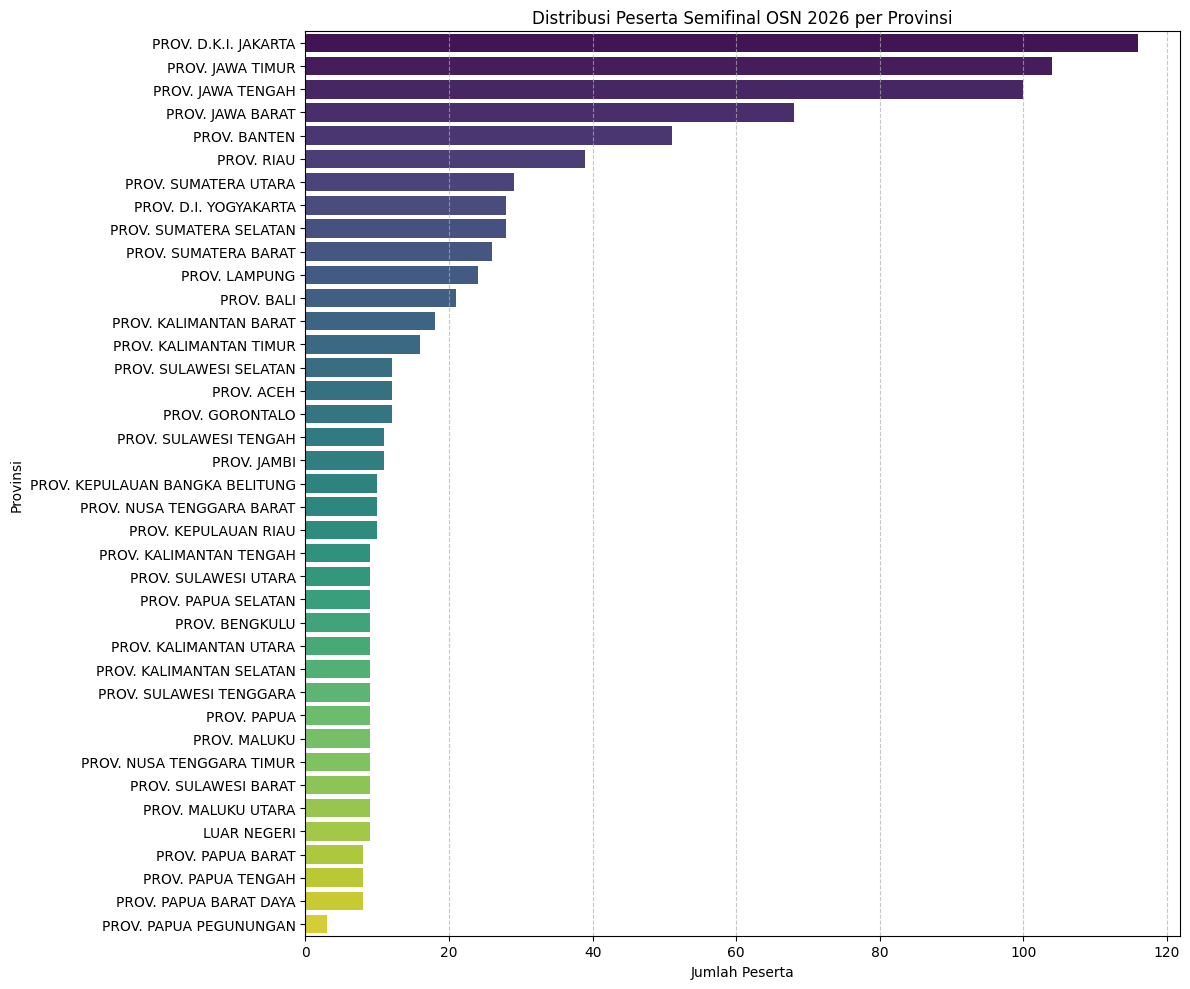

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Menghitung jumlah peserta per provinsi
provinsi_counts = df['PROVINSI'].value_counts().reset_index()
provinsi_counts.columns = ['PROVINSI', 'JUMLAH_PESERTA']

# Membuat visualisasi
plt.figure(figsize=(12, 10))
sns.barplot(x='JUMLAH_PESERTA', y='PROVINSI', data=provinsi_counts, palette='viridis', hue='PROVINSI', legend=False)

plt.title('Distribusi Peserta Semifinal OSN 2026 per Provinsi')
plt.xlabel('Jumlah Peserta')
plt.ylabel('Provinsi')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [8]:
# 1. Mendapatkan daftar 10 provinsi terbanyak
top_10_provinsi = df['PROVINSI'].value_counts().nlargest(10).index

# 2. Memfilter dataframe hanya untuk 10 provinsi tersebut
df_top10 = df[df['PROVINSI'].isin(top_10_provinsi)]

# 3. Membuat tabel distribusi (cross-tabulation) antara Provinsi dan Cabang
distribusi_bidang = pd.crosstab(df_top10['PROVINSI'], df_top10['CABANG'])

# 4. Menampilkan hasil yang diurutkan berdasarkan total peserta terbanyak
distribusi_bidang = distribusi_bidang.loc[top_10_provinsi]

print("--- Distribusi Peserta per Bidang pada Top 10 Provinsi ---")
display(distribusi_bidang)

--- Distribusi Peserta per Bidang pada Top 10 Provinsi ---


CABANG,ASTRONOMI,BIOLOGI,EKONOMI,FISIKA,GEOGRAFI,INFORMATIKA,KEBUMIAN,KIMIA,MATEMATIKA
PROVINSI,,,,,,,,,
PROV. D.K.I. JAKARTA,11,13,13,15,9,15,15,12,13
PROV. JAWA TIMUR,10,15,11,11,10,12,13,7,15
PROV. JAWA TENGAH,15,14,8,9,10,6,15,11,12
PROV. JAWA BARAT,7,5,7,7,10,9,8,8,7
PROV. BANTEN,5,4,7,5,5,8,5,6,6
PROV. RIAU,6,3,7,3,4,4,3,5,4
PROV. SUMATERA UTARA,6,1,6,4,1,2,1,3,5
PROV. D.I. YOGYAKARTA,1,3,1,4,8,4,4,2,1
PROV. SUMATERA SELATAN,1,7,5,2,2,5,2,3,1


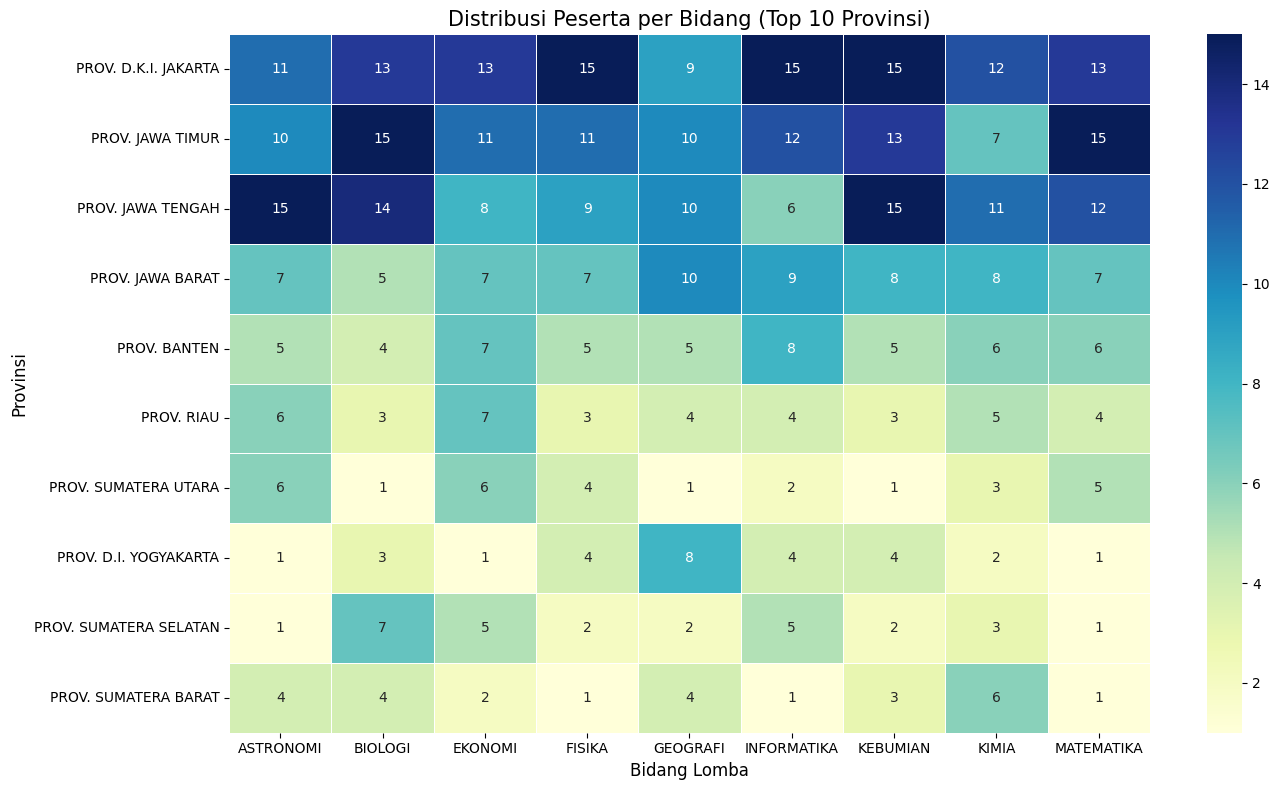

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Membuat heatmap untuk distribusi bidang pada Top 10 Provinsi
plt.figure(figsize=(14, 8))
sns.heatmap(distribusi_bidang, annot=True, cmap='YlGnBu', fmt='d', linewidths=.5)

plt.title('Distribusi Peserta per Bidang (Top 10 Provinsi)', fontsize=15)
plt.xlabel('Bidang Lomba', fontsize=12)
plt.ylabel('Provinsi', fontsize=12)

plt.tight_layout()
plt.show()